In [1]:
import pandas as pd
import numpy as np

<Axes: title={'center': 'Monthly Airline Passengers'}, xlabel='Month'>

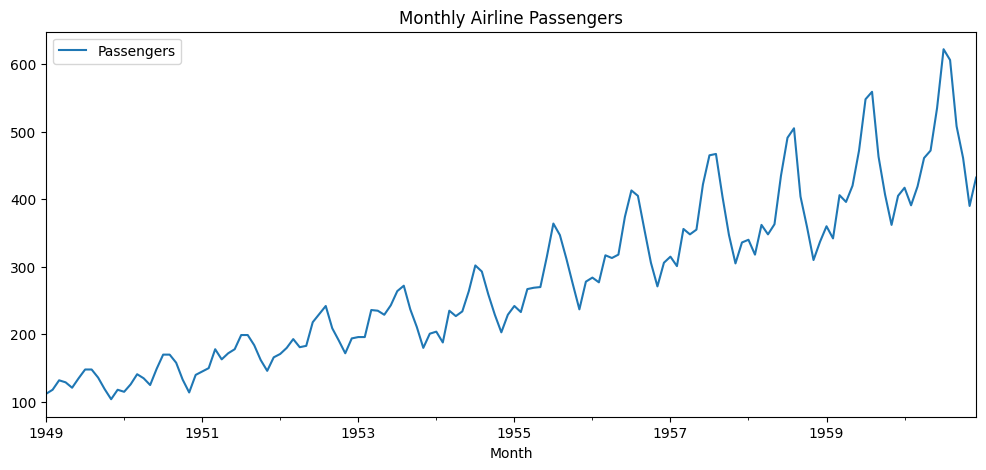

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
df.plot(figsize=(12,5), title='Monthly Airline Passengers')

In [3]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Passengers'])
print(result[1])  # p-value


0.991880243437641


In [4]:
df['Diff'] = df['Passengers'].diff()
df['Seasonal_Diff'] = df['Passengers'].diff(12)


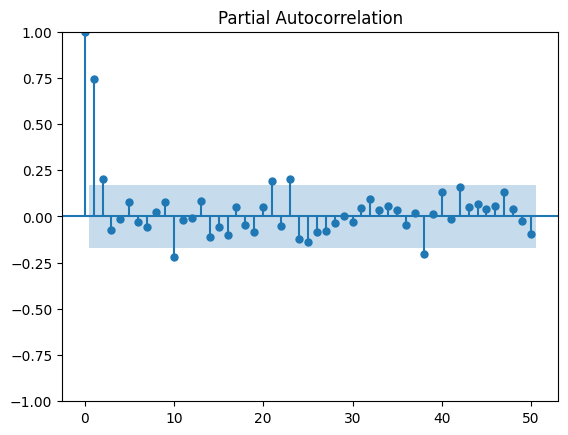

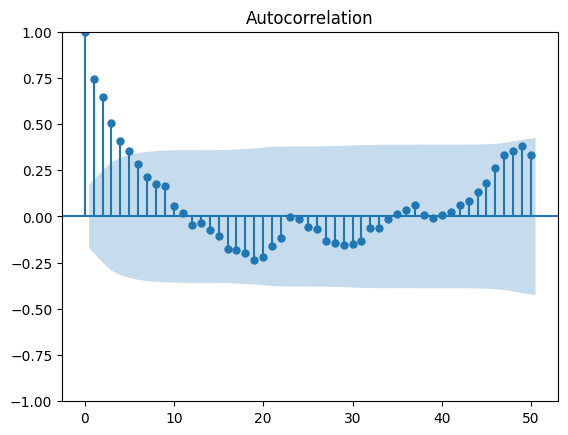

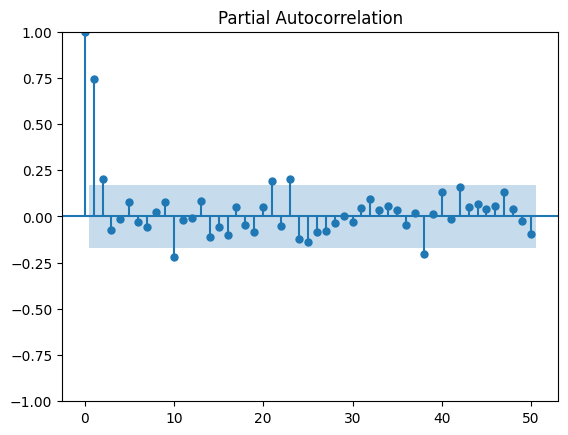

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df['Seasonal_Diff'].dropna(), lags=50)
plot_pacf(df['Seasonal_Diff'].dropna(), lags=50)


In [11]:
df.index.freq = 'MS'

from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(df['Passengers'],
                order=(1,1,1),
                seasonal_order=(1,1,1,12),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(method='powell')
print(results.summary())


Optimization terminated successfully.
         Current function value: 3.175051
         Iterations: 2
         Function evaluations: 107
                                     SARIMAX Results                                      
Dep. Variable:                         Passengers   No. Observations:                  144
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -457.207
Date:                            Mon, 08 Sep 2025   AIC                            924.415
Time:                                    22:33:03   BIC                            938.225
Sample:                                01-01-1949   HQIC                           930.022
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------

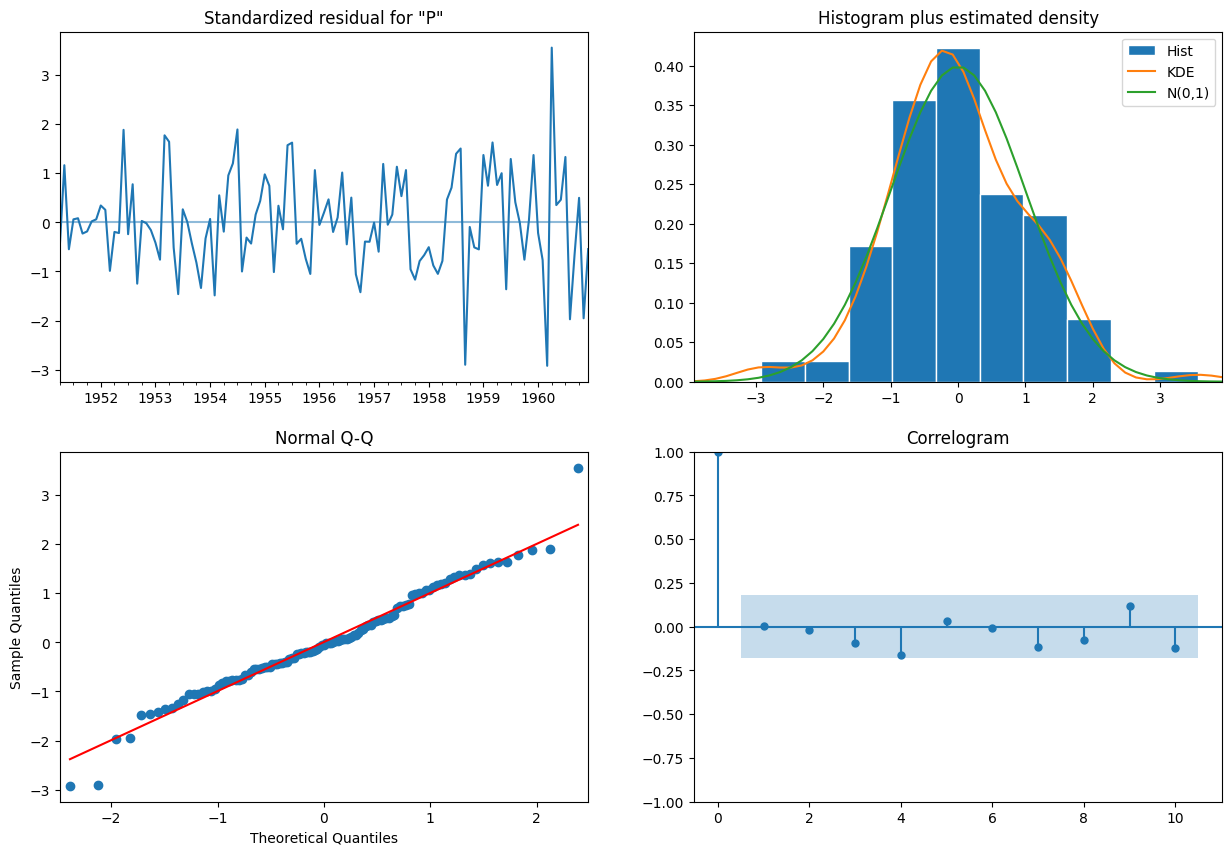

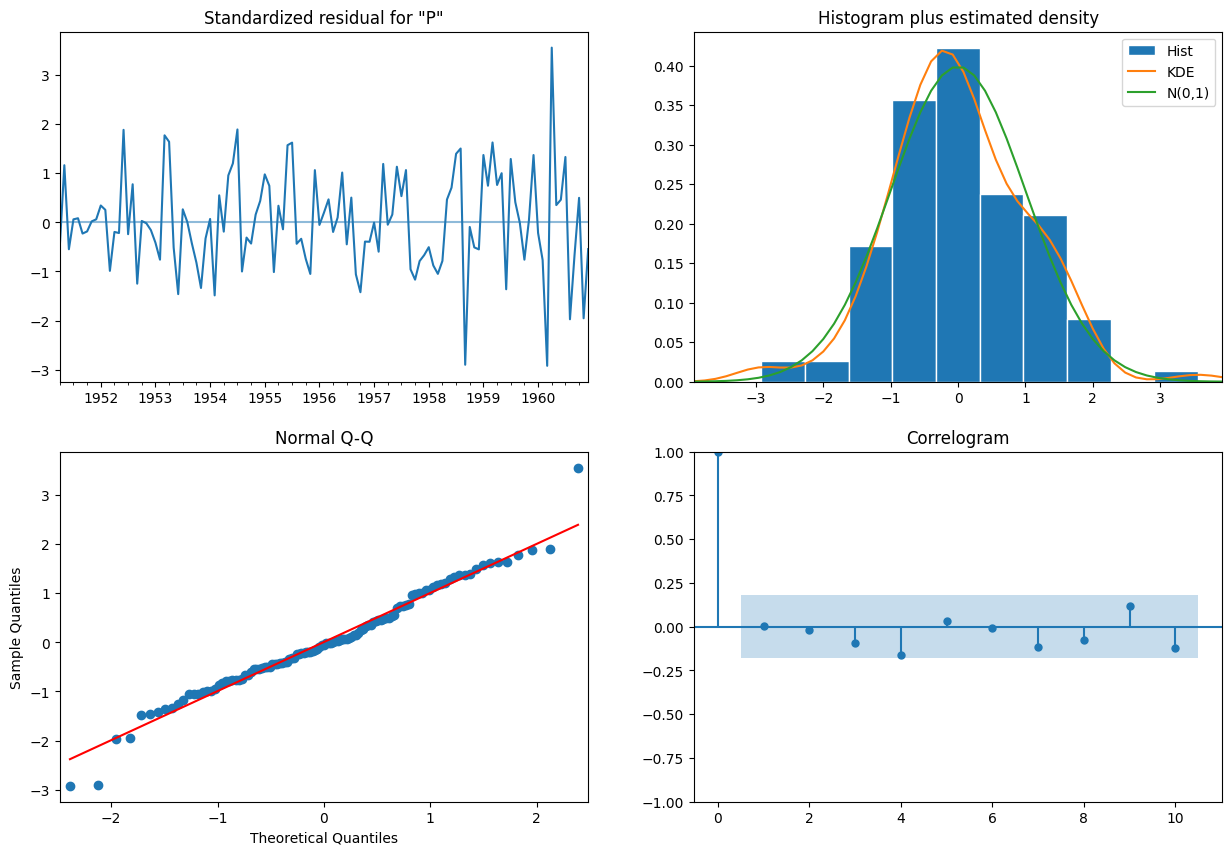

In [7]:
results.plot_diagnostics(figsize=(15,10))


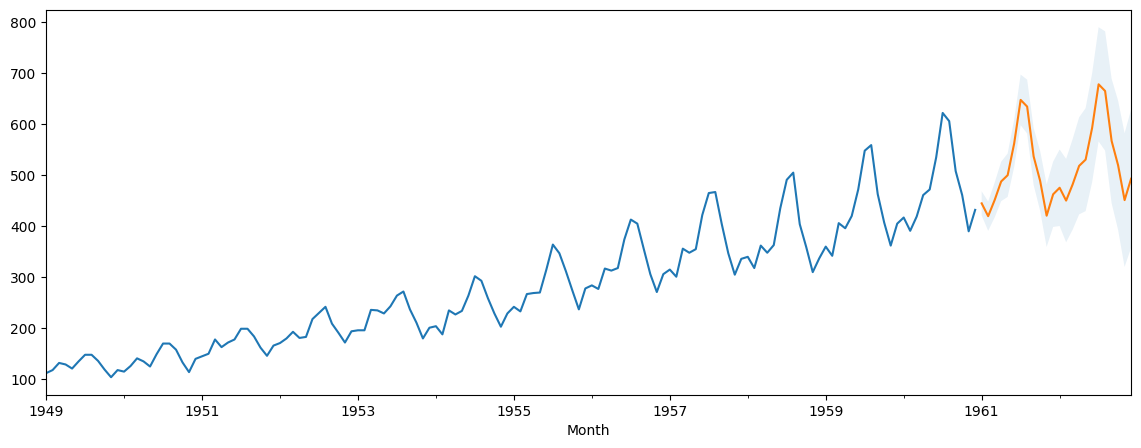

In [12]:
forecast = results.get_forecast(steps=24)
pred_ci = forecast.conf_int()

ax = df['Passengers'].plot(label='Observed', figsize=(14,5))
forecast.predicted_mean.plot(ax=ax, label='Forecast')
ax.fill_between(pred_ci.index, pred_ci.iloc[:,0], pred_ci.iloc[:,1], alpha=0.1)


In [3]:
! uv pip install --upgrade numpy
! uv pip install --force-reinstall pmdarima --no-deps

Using Python 3.12.11 environment at: D:\Lens\.venv
Resolved 1 package in 62ms
Audited 1 package in 0.39ms
Using Python 3.12.11 environment at: D:\Lens\.venv
Resolved 1 package in 1.05s
Prepared 1 package in 1ms
Uninstalled 1 package in 38ms
Installed 1 package in 129ms
 ~ pmdarima==2.0.4


In [ ]:
from pmdarima import auto_arima

auto_model = auto_arima(df['Passengers'], seasonal=True, m=12,
                        trace=True, suppress_warnings=True)
print(auto_model.summary())
